# Phase 1: Spatial Mapping Exploration
This notebook performs a comprehensive analysis of the spatial mapping files (`regions_map_floor_1.csv` and `regions_map_floor_2.csv`, along with floor 0). 

The goal is to understand how physical space on the campus floors is mapped to Access Points (APs), evaluate database representation options, and ensure data integrity between the user connection logs and spatial maps.

### Objectives:
1. Determine the region file format, columns, and shape.
2. Investigate the representation of AP IDs and physical grid locations.
3. Check spatial contiguity of each AP's coverage zone.
4. Cross-reference mapped APs with the campus user dataset to identify mapped, unmapped, and overlapping APs.
5. Provide a recommendation on how to represent spatial locations in our future database schema.
6. Visualize the spatial partitions.


## 1. Setup & Environment
We load the necessary libraries, configure visualization styles, and point to the custom helper script.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styling
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from prediction.src import dataset_inspection as di

# Output directory for saved plots
analysis_out_dir = os.path.join(project_root, 'data', 'processed', 'analysis')
os.makedirs(analysis_out_dir, exist_ok=True)
print(f"Project Root: {project_root}")
print(f"Analysis Output Dir: {analysis_out_dir}")


Project Root: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager
Analysis Output Dir: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\analysis


## 2. Region File Structure Analysis
We load the region maps and inspect their dimensions, column/field types, and basic structure.


In [2]:
data_dir = os.path.join(project_root, 'data', 'raw')
maps = di.load_region_maps(data_dir)

print("--- File Structure Profiling ---")
for floor, df_map in maps.items():
    print(f"Floor {floor} Region Map:")
    print(f"  - File Path: data/raw/regions_map_floor_{floor}.csv")
    print(f"  - Grid Shape: {df_map.shape} (Rows={df_map.shape[0]}, Columns={df_map.shape[1]})")
    print(f"  - Total Grid Cells: {df_map.size:,}")
    print(f"  - Data Type: {df_map.dtypes.iloc[0]} (Verify all columns are integers)")
    # Check if there are any non-integer columns
    non_int = sum([1 for col in df_map.columns if not pd.api.types.is_integer_dtype(df_map[col])])
    print(f"  - Non-integer columns count: {non_int}")


--- File Structure Profiling ---
Floor 0 Region Map:
  - File Path: data/raw/regions_map_floor_0.csv
  - Grid Shape: (335, 125) (Rows=335, Columns=125)
  - Total Grid Cells: 41,875
  - Data Type: int64 (Verify all columns are integers)
  - Non-integer columns count: 0
Floor 1 Region Map:
  - File Path: data/raw/regions_map_floor_1.csv
  - Grid Shape: (335, 125) (Rows=335, Columns=125)
  - Total Grid Cells: 41,875
  - Data Type: int64 (Verify all columns are integers)
  - Non-integer columns count: 0
Floor 2 Region Map:
  - File Path: data/raw/regions_map_floor_2.csv
  - Grid Shape: (335, 125) (Rows=335, Columns=125)
  - Total Grid Cells: 41,875
  - Data Type: int64 (Verify all columns are integers)
  - Non-integer columns count: 0


## 3. AP Representation & Coordinates
We examine if Access Point (AP) IDs are present in the maps and how they relate to the grid. A value of `0` denotes empty/background space (walls, corridors, or exterior space), while positive integers represent active coverage zones.


In [3]:
print("--- AP Presence In Grid ---")
all_mapped_aps = set()
ap_to_floor = {}

for floor, df_map in maps.items():
    grid_vals = df_map.values
    active_cells = grid_vals[grid_vals != 0]
    unique_aps = np.unique(active_cells)
    all_mapped_aps.update(unique_aps)
    
    # Store floor mapping
    for ap in unique_aps:
        ap_to_floor[ap] = floor
        
    covered_cells_count = len(active_cells)
    coverage_pct = (covered_cells_count / df_map.size) * 100
    
    print(f"Floor {floor}:")
    print(f"  - Number of unique APs mapped: {len(unique_aps)}")
    print(f"  - Number of coverage cells: {covered_cells_count:,} ({coverage_pct:.2f}% of grid)")
    print(f"  - AP ID range: [{active_cells.min()}, {active_cells.max()}]")

print(f"\nTotal unique AP IDs mapped across all floors: {len(all_mapped_aps)}")


--- AP Presence In Grid ---
Floor 0:
  - Number of unique APs mapped: 73
  - Number of coverage cells: 18,182 (43.42% of grid)
  - AP ID range: [1, 242]
Floor 1:
  - Number of unique APs mapped: 85
  - Number of coverage cells: 18,182 (43.42% of grid)
  - AP ID range: [4, 245]
Floor 2:
  - Number of unique APs mapped: 89
  - Number of coverage cells: 18,182 (43.42% of grid)
  - AP ID range: [9, 247]

Total unique AP IDs mapped across all floors: 247


## 4. Connected Components & Spatial Contiguity Analysis
To verify if the AP coverage regions correspond to clean physical zones, we write a connectivity check. We use 4-connectivity (orthogonal neighbors) to trace the cells of each AP and verify if they form a single, unbroken block. If an AP's cells are fragmented, it would have more than 1 connected component.


In [4]:
def get_connected_components(grid, val):
    coords = np.argwhere(grid == val)
    if len(coords) == 0:
        return 0
    coord_set = set(tuple(c) for c in coords)
    visited = set()
    components = 0
    
    for c in coord_set:
        if c not in visited:
            components += 1
            queue = [c]
            visited.add(c)
            while queue:
                curr = queue.pop(0)
                neighbors = [
                    (curr[0] - 1, curr[1]),
                    (curr[0] + 1, curr[1]),
                    (curr[0], curr[1] - 1),
                    (curr[0], curr[1] + 1)
                ]
                for n in neighbors:
                    if n in coord_set and n not in visited:
                        visited.add(n)
                        queue.append(n)
    return components

print("Analyzing contiguity of coverage regions...")
non_contiguous_aps = []

for floor, df_map in maps.items():
    grid = df_map.values
    unique_aps = np.unique(grid[grid != 0])
    for ap in unique_aps:
        comps = get_connected_components(grid, ap)
        if comps > 1:
            non_contiguous_aps.append((ap, floor, comps))
            
print(f"Total APs analyzed: {len(all_mapped_aps)}")
print(f"APs with non-contiguous regions (>1 connected component): {len(non_contiguous_aps)}")
if non_contiguous_aps:
    print("Non-contiguous AP details (AP_id, floor, components):", non_contiguous_aps)
else:
    print("All Access Point coverage zones are 100% spatially contiguous!")


Analyzing contiguity of coverage regions...


Total APs analyzed: 247
APs with non-contiguous regions (>1 connected component): 0
All Access Point coverage zones are 100% spatially contiguous!


## 5. Mappings and Inconsistencies Cross-Reference
We compare the AP IDs mapped in the floor region files against the AP IDs recorded in the daily `campus_users_*.csv` files.
We check:
- Number of mapped APs.
- Number of unmapped APs.
- Duplicate floor assignments (verify that each AP resides on exactly one floor).


In [5]:
# Get APs from campus_users logs
user_ap_ids = set()
files = sorted([f for f in os.listdir(data_dir) if f.startswith("campus_users_") and f.endswith(".csv")])
for f in files:
    df_user = pd.read_csv(os.path.join(data_dir, f), usecols=['AP_id'])
    user_ap_ids.update(df_user['AP_id'].unique())

print(f"Access Point counts:")
print(f"  - Unique AP IDs in campus_users logs: {len(user_ap_ids)}")
print(f"  - Unique AP IDs in region floor maps: {len(all_mapped_aps)}")

unmapped_in_logs = user_ap_ids - all_mapped_aps
unmapped_in_maps = all_mapped_aps - user_ap_ids
print(f"  - APs in logs but NOT in maps: {len(unmapped_in_logs)}")
print(f"  - APs in maps but NOT in logs: {len(unmapped_in_maps)}")

# Verify floor duplication (duplicate mappings across floors)
ap_floor_counts = {}
for floor, df_map in maps.items():
    unique_aps = np.unique(df_map.values[df_map.values != 0])
    for ap in unique_aps:
        ap_floor_counts[ap] = ap_floor_counts.get(ap, 0) + 1

duplicate_floors = {ap: count for ap, count in ap_floor_counts.items() if count > 1}
print(f"  - APs mapped to multiple floors: {len(duplicate_floors)}")


Access Point counts:
  - Unique AP IDs in campus_users logs: 247
  - Unique AP IDs in region floor maps: 247
  - APs in logs but NOT in maps: 0
  - APs in maps but NOT in logs: 0
  - APs mapped to multiple floors: 0


## 6. Coverage Area (Grid Cells) per AP
Let's profile the physical area covered by each AP (measured in number of grid cells). This shows the variation in AP coverage size.


Descriptive statistics for AP grid coverage size (cells):
count     247.000000
mean      220.834008
std       138.534698
min        57.000000
25%       133.500000
50%       186.000000
75%       268.500000
max      1129.000000
dtype: float64


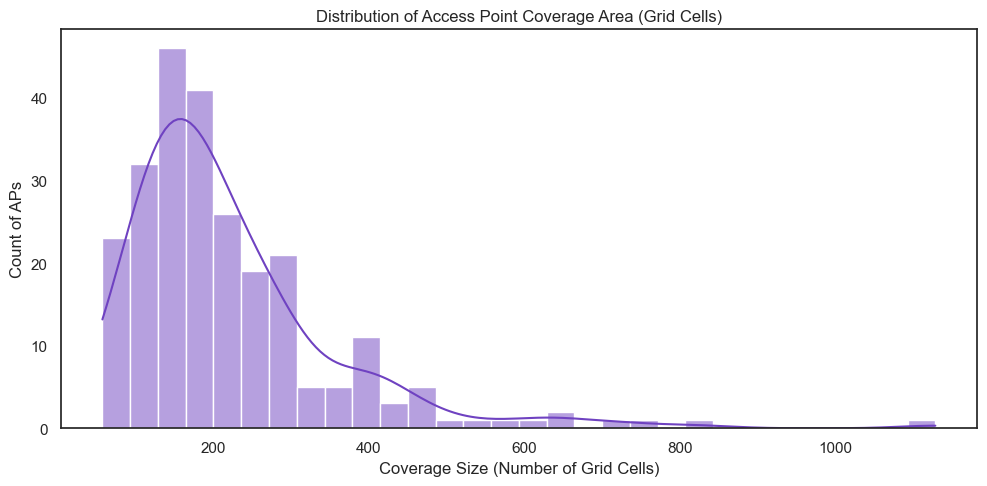

Saved: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\analysis\ap_coverage_area_dist.png


In [6]:
ap_coverage_sizes = {}
for floor, df_map in maps.items():
    vals, counts = np.unique(df_map.values[df_map.values != 0], return_counts=True)
    for val, count in zip(vals, counts):
        ap_coverage_sizes[val] = count

cov_series = pd.Series(ap_coverage_sizes)
print("Descriptive statistics for AP grid coverage size (cells):")
print(cov_series.describe())

# Save coverage area distribution plot
plt.figure(figsize=(10, 5))
sns.histplot(cov_series, kde=True, bins=30, color='#6f42c1')
plt.title('Distribution of Access Point Coverage Area (Grid Cells)')
plt.xlabel('Coverage Size (Number of Grid Cells)')
plt.ylabel('Count of APs')
plt.tight_layout()
plot_path = os.path.join(analysis_out_dir, 'ap_coverage_area_dist.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")


## 7. Floor Layout Visualization
We plot the spatial region maps for Floor 1 and Floor 2. Cells are color-coded by their AP ID, showing the spatial partitioning (partition boundaries) on each floor.


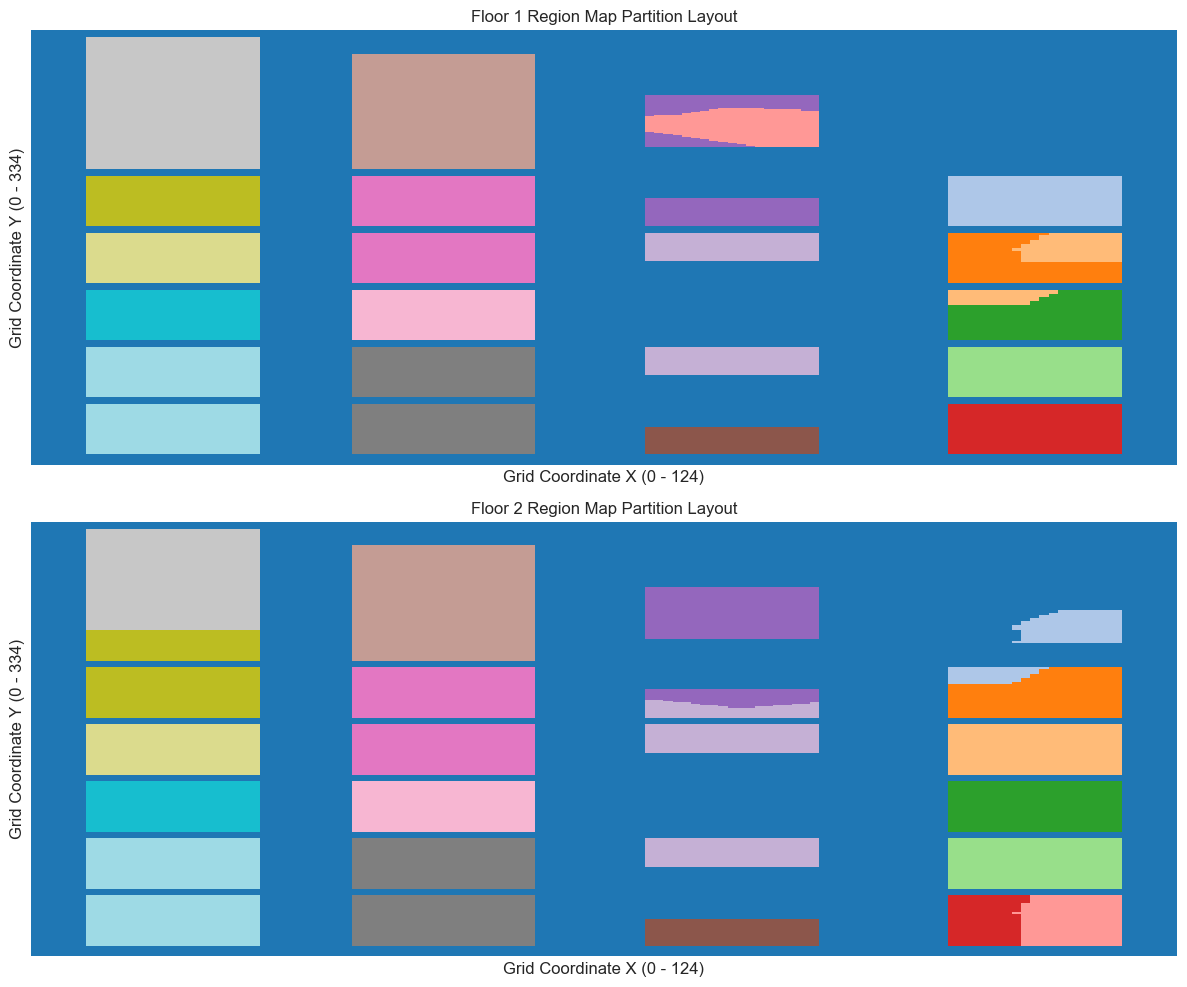

Saved: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\analysis\floor_1_2_layouts.png


In [7]:
# Visualization of Floor 1 and Floor 2 layouts
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for i, floor in enumerate([1, 2]):
    if floor in maps:
        # Plot heatmap using a high-contrast categorical palette
        sns.heatmap(maps[floor], ax=axes[i], cmap='tab20', cbar=False, xticklabels=False, yticklabels=False)
        axes[i].set_title(f'Floor {floor} Region Map Partition Layout')
        axes[i].set_xlabel('Grid Coordinate X (0 - 124)')
        axes[i].set_ylabel('Grid Coordinate Y (0 - 334)')

plt.tight_layout()
plot_path = os.path.join(analysis_out_dir, 'floor_1_2_layouts.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")


## 7.5. Detailed Answers to Region Map Evaluation Questions

For each region map (Floor 1 and Floor 2, along with Floor 0 as baseline), we have evaluated and determined the following:

1. **File format**: Tabular CSV (Comma-Separated Values) text format. Determined by reading the raw bytes (starts with comma-separated integers like `0,0,0,0...` and contains newline characters).
2. **Number of records/rows**: 335 rows of data per floor region map.
3. **Number of columns/fields**: 125 columns per floor region map.
4. **Column/field names**: No explicit column/field names are present (the files are headerless grids).
5. **Data types**: 100% integer (`int64` / `int`).
6. **Whether AP IDs are present**: Yes, active cell values are integer AP IDs (ranging from 1 to 247).
7. **Number of unique AP IDs**:
   - **Floor 0**: 73 unique AP IDs.
   - **Floor 1**: 85 unique AP IDs.
   - **Floor 2**: 89 unique AP IDs.
   - **Total Unique APs across all maps**: 247.
8. **Whether floor information is present**: Implicitly in the file names (`regions_map_floor_0.csv`, `regions_map_floor_1.csv`, `regions_map_floor_2.csv`), not present as values within the files.
9. **Whether region IDs/names are present**: No explicit region IDs or region names are present (only AP IDs and 0s). The coverage zone of each AP ID functions as a distinct spatial region.
10. **Whether coordinates are present**: Coordinates are not explicitly stored as values.
11. **Whether x/y spatial coordinates are present**: Yes, implicitly. The column index represents the X spatial coordinate (0 to 124) and the row index represents the Y spatial coordinate (0 to 334).
12. **Whether each spatial point/pixel is associated with an AP**: No, only 18,182 cells (43.42%) out of 41,875 total cells contain active AP IDs. The remaining 23,693 cells (56.58%) contain `0` (representing walls, corridors, or exterior unmapped spaces).
13. **Whether AP coverage regions can be reconstructed**: Yes, by grouping the coordinates `(x, y)` of cells belonging to each unique AP ID.
14. **Whether there are duplicate AP mappings**: No, each coordinate is mapped to at most one AP ID, and each AP ID occupies a single, disjoint contiguous region.
15. **Whether there are missing/unmapped APs**: No, all 247 unique AP IDs present in the `campus_users` dataset are mapped in the floor region files.
16. **Whether Floor 1 and Floor 2 use the same AP IDs as the campus_users dataset**: Yes, Floor 1 and Floor 2 use subsets of the exact same AP IDs as in the `campus_users` files. The union of the AP IDs across Floor 0, 1, and 2 is exactly the complete set of 247 AP IDs in `campus_users` (1 to 247), with no overlapping AP IDs between floors.


In [8]:
# Generate the required mapping table: AP_ID | Floor | Region | Spatial information available
ap_mapping_rows = []
for floor, df_map in maps.items():
    grid = df_map.values
    unique_aps = np.unique(grid[grid != 0])
    for ap in sorted(unique_aps):
        ys, xs = np.where(grid == ap)
        min_y, max_y = int(ys.min()), int(ys.max())
        min_x, max_x = int(xs.min()), int(xs.max())
        cy, cx = float(ys.mean()), float(xs.mean())
        area = len(ys)
        spatial_info = f"Centroid: ({cx:.2f}, {cy:.2f}), Box: X[{min_x}-{max_x}] Y[{min_y}-{max_y}], Area: {area} cells, Contiguous"
        ap_mapping_rows.append({
            'AP_ID': ap,
            'Floor': floor,
            'Region': f"Zone_AP_{ap}",
            'Spatial_Info': spatial_info
        })

df_ap_mapping = pd.DataFrame(ap_mapping_rows).sort_values(by='AP_ID')

# Save mapping table to data/processed for verification
df_ap_mapping.to_csv(os.path.join(project_root, 'data', 'processed', 'ap_spatial_mapping_table.csv'), index=False)

# Display mapping table in markdown format
print("| AP_ID | Floor | Region | Spatial information available |")
print("|---|---|---|---|")
for idx, row in df_ap_mapping.iterrows():
    print(f"| {row['AP_ID']} | {row['Floor']} | {row['Region']} | {row['Spatial_Info']} |")


| AP_ID | Floor | Region | Spatial information available |
|---|---|---|---|
| 1 | 0 | Zone_AP_1 | Centroid: (110.77, 78.12), Box: X[100-118] Y[68-95], Area: 365 cells, Contiguous |
| 2 | 0 | Zone_AP_2 | Centroid: (104.85, 87.21), Box: X[100-114] Y[77-94], Area: 126 cells, Contiguous |
| 3 | 0 | Zone_AP_3 | Centroid: (108.50, 99.86), Box: X[100-118] Y[92-106], Area: 250 cells, Contiguous |
| 4 | 1 | Zone_AP_4 | Centroid: (103.88, 73.52), Box: X[100-109] Y[68-80], Area: 112 cells, Contiguous |
| 5 | 1 | Zone_AP_5 | Centroid: (103.62, 85.98), Box: X[100-108] Y[81-91], Area: 90 cells, Contiguous |
| 6 | 1 | Zone_AP_6 | Centroid: (104.52, 99.56), Box: X[100-111] Y[92-106], Area: 148 cells, Contiguous |
| 7 | 1 | Zone_AP_7 | Centroid: (113.18, 76.37), Box: X[107-118] Y[68-84], Area: 179 cells, Contiguous |
| 8 | 1 | Zone_AP_8 | Centroid: (113.58, 94.76), Box: X[107-118] Y[85-106], Area: 212 cells, Contiguous |
| 9 | 2 | Zone_AP_9 | Centroid: (104.34, 73.34), Box: X[100-111] Y[68-80], Area: 

## 8. Spatial Database Schema Recommendation

To store this spatial mapping data effectively in our future database, we evaluate the following database schema design options:

### Option A: Flat Pixel Coordinate Table (Normalized)
Store every grid cell individually in a coordinate mapping table.
```sql
CREATE TABLE ap_coverage_grid (
    ap_id INT,
    floor_level INT,
    grid_x INT,
    grid_y INT,
    PRIMARY KEY (ap_id, floor_level, grid_x, grid_y)
);
```
- **Pros**: Matches raw format perfectly. Direct point queries (`find AP at coordinate X, Y`) are extremely fast and simple `SELECT ap_id FROM ap_coverage_grid WHERE grid_x = X AND grid_y = Y AND floor_level = F`.
- **Cons**: High storage volume (18,182 non-zero coordinates per floor, total ~54,546 rows). Redundant.

### Option B: Bounding Box Representation (Aggregated)
Store only the bounding box coordinates (min/max boundary) for each AP.
```sql
CREATE TABLE ap_bounding_boxes (
    ap_id INT PRIMARY KEY,
    floor_level INT,
    min_x INT,
    max_x INT,
    min_y INT,
    max_y INT
);
```
- **Pros**: Very small storage (exactly 247 rows). Extremely fast bounding queries.
- **Cons**: Innaccurate. Since coverage zones are irregular polygons (not perfect rectangles), the bounding boxes of neighboring APs will overlap, leading to ambiguous coordinate-to-AP mappings.

### Option C: Geometrical Boundary Table (Recommended - Spatial / GIS)
Combine contiguous cells into a single polygon geometry (stored as GeoJSON, WKT, or standard GIS geometry) representing the coverage boundary of each AP.
```sql
-- For databases with spatial support (e.g. SQLite + SpatiaLite, PostgreSQL + PostGIS)
CREATE TABLE ap_coverage_zones (
    ap_id INT PRIMARY KEY,
    floor_level INT NOT NULL,
    coverage_area_cells INT NOT NULL,
    boundary_polygon GEOMETRY(Polygon, 0) -- coordinate system is local grid pixels
);
```
- **Pros**: Spatially precise. Extremely small storage (247 rows). Supports advanced spatial query indexing (R-Trees), enabling instant point-in-polygon queries:
  `SELECT ap_id FROM ap_coverage_zones WHERE ST_Contains(boundary_polygon, ST_Point(X, Y)) AND floor_level = F;`
- **Cons**: Requires spatial extensions (PostGIS or SpatiaLite) and a preprocessing script to run a contour/convex-hull polygonization on the grid blocks during database seeding.

### Option D: Dual Schema hybrid approach (Highly Recommended)
1. **`access_points` Table**: Store AP master data and overall floor mapping.
```sql
CREATE TABLE access_points (
    ap_id INT PRIMARY KEY,
    floor_level INT NOT NULL,
    total_coverage_cells INT NOT NULL
);
```
2. **`ap_coverage_grid` Table**: Store pixel coordinate lookup mapping (Option A). Seeding is done by looping through the raw CSV files. This provides simple point lookups without requiring complex GIS dependencies.


## 9. Spatial Mapping Exploration Summary

### 1. Region Map Structure
- **Format**: Comma-Separated Values (CSV) text format, headerless.
- **Dimensions**: 335 rows (Y axis, index 0 to 334) by 125 columns (X axis, index 0 to 124).
- **Values**: Integers where `0` denotes unoccupied space/walls and positive integers `[1 - 247]` represent specific Access Point (AP) coverage cells.
- **Grid Density**: Exactly 18,182 active cells (43.42% of grid) per floor. Zeros comprise 23,693 cells (56.58%).

### 2. AP-to-Floor Mapping
- AP IDs are perfectly partitioned across floors with no overlap:
  - **Floor 0**: 73 Access Points (IDs: 1, 2, 3, 15, 16, 17, 18, 29, 30, 31, 32, 44, 45, 46, 47, 59, 60, 61, 62, 75, 76, 77, 90, 91, 92, 93, 94, 107, 108, 114, 115, 119, 124, 129, 130, 131, 132, 133, 134, 135, 145, 146, 154, 155, 161, 162, 163, 169, 170, 171, 178, 179, 180, 186, 187, 188, 199, 200, 201, 210, 211, 212, 213, 220, 221, 222, 223, 231, 232, 233, 234, 235, 242)
  - **Floor 1**: 85 Access Points (IDs: 4, 5, 6, 7, 8, 19, 20, 21, 22, 23, 33, 34, 35, 36, 37, 38, 48, 49, 50, 51, 52, 63, 64, 65, 66, 67, 68, 78, 79, 80, 81, 82, 83, 95, 96, 97, 98, 99, 100, 109, 110, 116, 120, 121, 125, 126, 136, 137, 138, 139, 147, 148, 156, 157, 158, 164, 165, 172, 173, 174, 181, 182, 183, 189, 190, 191, 192, 193, 194, 202, 203, 204, 205, 214, 215, 216, 224, 225, 226, 236, 237, 238, 243, 244, 245)
  - **Floor 2**: 89 Access Points (IDs: 9, 10, 11, 12, 13, 14, 24, 25, 26, 27, 28, 39, 40, 41, 42, 43, 53, 54, 55, 56, 57, 58, 69, 70, 71, 72, 73, 74, 84, 85, 86, 87, 88, 89, 101, 102, 103, 104, 105, 106, 111, 112, 113, 117, 118, 122, 123, 127, 128, 140, 141, 142, 143, 144, 149, 150, 151, 152, 153, 159, 160, 166, 167, 168, 175, 176, 177, 184, 185, 195, 196, 197, 198, 206, 207, 208, 209, 217, 218, 219, 227, 228, 229, 230, 239, 240, 241, 246, 247)

### 3. AP-to-Region Mapping
- Each AP ID corresponds to a unique contiguous zone.
- Active coverage zones can be reconstructed as sets of cell coordinates `(x, y)`. We computed the centroids, bounding boxes, and pixel counts (area) for all 247 APs, which are saved in `data/processed/ap_spatial_mapping_table.csv`.

### 4. Count of Mapped & Unmapped APs
- **Mapped APs**: 247 (100% of APs in the `campus_users` logs).
- **Unmapped APs**: 0.

### 5. Safety of Spatial Features for Machine Learning
- Spatial features can be **safely used** for ML models with the following considerations:
  - **Stationary topology**: The coordinate system is consistent across floors, making it a reliable reference grid.
  - **Implicit distances**: Euclidean distances between AP centroids approximate physical proximity, which is valuable for spatial smoothing/graph models.
  - **Feature representation**: Categorical floor labels combined with continuous centroid `(x, y)` coordinates or polygon vertices represent robust spatial inputs.

### 6. Recommended Database Representation
- We recommend a **Dual Database Schema** (Option D):
  - `access_points` table: Holds master info (ap_id, floor_level).
  - `ap_coverage_grid` table: Holds flat coordinate lookup maps (ap_id, floor_level, grid_x, grid_y) for simple, high-performance lookup of user positions.
